# Object segmentation network

Import libraries

In [11]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np

from torchvision import transforms
from torch.utils.data import DataLoader

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import torchvision.transforms as T
import torch.optim as optim
import torchvision

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as patches


Data loader implementation

In [13]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths, self.annotation_paths = self.collect_paths(root_dir)

    def collect_paths(self, root_dir):
        image_paths = []
        annotation_paths = []

        annotation_root = os.path.join(root_dir, "Annotations")
        image_root = os.path.join(root_dir, "Images")

        for subdir in os.listdir(annotation_root):
            annotation_subfolder = os.path.join(annotation_root, subdir)
            image_subfolder = os.path.join(image_root, subdir)

            if os.path.isdir(annotation_subfolder) and os.path.isdir(image_subfolder):
                for filename in os.listdir(annotation_subfolder):
                    if filename.endswith(".txt"):
                        annotation_path = os.path.join(annotation_subfolder, filename)
                        image_filename = os.path.splitext(filename)[0] + ".jpg"
                        image_path = os.path.join(image_subfolder, image_filename)
                        if os.path.exists(image_path):
                            annotation_paths.append(annotation_path)
                            image_paths.append(image_path)

        return image_paths, annotation_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        annotation_path = self.annotation_paths[idx]

        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        # Load and parse annotation (you'll need to implement this part based on the content of your annotation file)
        boxes = self.parse_annotation(annotation_path)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        num_objs = len(boxes) 
        
        if num_objs == 0:
            # area = torch.tensor([ 0.0 ])
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] -     boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
            
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

    def parse_annotation(self, annotation_path):
        with open(annotation_path, 'r') as file:
            lines = file.readlines()

        num_objects = int(lines[0].strip())
        bounding_boxes = []

        for i in range(1, num_objects + 1):
            values = list(map(int, lines[i].strip().split()))
            if len(values) == 4:
                bounding_boxes.append(values)

        return bounding_boxes

Initialize the data loader

In [14]:
# Define your data transformation (e.g., resizing, normalization, etc.)
transform = transforms.Compose([
    transforms.Resize((560, 480)),
    transforms.ToTensor(),
])

# Create an instance of the custom dataset
dataset = CustomDataset(root_dir='./data/TrainValid/TrainValid', transform=transform) # path is correct

# Create a DataLoader to iterate through the dataset
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

Test the data loader (re-run this cell to see different examples)

tensor([[299.,   2., 498.,  96.]])


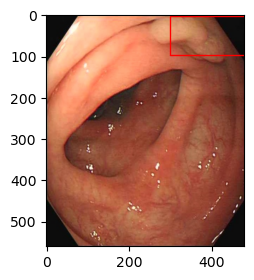

tensor([[262., 196., 321., 247.]])


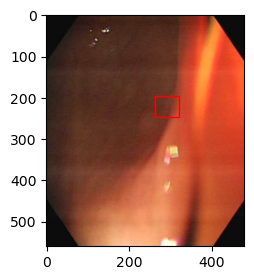

tensor([[196., 220., 290., 296.]])


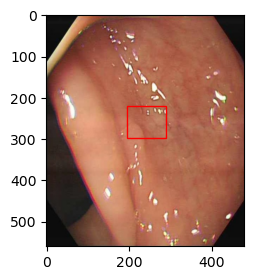

tensor([[112.,  56., 231., 110.]])


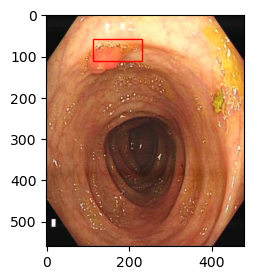

tensor([[206., 151., 316., 291.]])


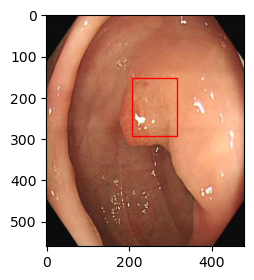

In [15]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    if bounding_boxes.numel() > 0:
        for box in bounding_boxes:
            print(box)
            box = box.squeeze(0) # flatten the tensor to avoid unpacking error
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

Select the device to train the model on (GPU by default if available)

In [16]:
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


True
Using device: cuda


Define the data collate function for the DataLoader (which combines multiple images into a batch)

In [19]:
def collate_fn(batch):
    images, targets = zip(*batch)  # Transpose the batch (turn list of pairs into pair of lists)

    images = list(image for image in images)
    targets = list(target for target in targets)

    images = torch.stack(images, dim=0)  # Stack images to create a 4D tensor

    # In case of targets, we don't stack or pad because Faster R-CNN can handle varying-size targets
    return images, targets

Define the model

In [29]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, collate_fn=collate_fn)

# Define the model
model = fasterrcnn_resnet50_fpn(weights=True)

# Modify the model for your specific dataset: Change the number of classes
# num_classes = 1 # 1 class (Polyp) + background
num_classes = 2  # 1 class (polyp) + 1 background

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

model = model.to(device)
print("Classes in the model's classifier:", model.roi_heads.box_predictor.cls_score.out_features)

Classes in the model's classifier: 2


Test the training of the model to see if it works 

In [33]:
# For Training
images, targets = next(iter(train_loader))
images = [image.to(device) for image in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to the device

output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.0930, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0738, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0345, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0123, device='cuda:0', grad_fn=<DivBackward0>)}


{'boxes': tensor([[ 71.7717, 248.0755, 282.3051, 366.5739],
        [237.5728, 103.9172, 349.6906, 427.5729],
        [133.3404,  18.1521, 317.2860, 313.3993],
        [236.7207, 135.1314, 380.9561, 320.4635],
        [188.5784,  65.1216, 305.2638, 366.2016],
        [102.0796, 223.2485, 236.2907, 461.2114],
        [291.7180, 183.7734, 402.0195, 457.4768],
        [199.1350, 314.7921, 438.0497, 425.7708],
        [ 87.9276, 200.4866, 327.4420, 330.1068],
        [131.3512, 238.9185, 357.3986, 365.9210],
        [212.5777, 198.2041, 393.0259, 396.7697],
        [281.5574,  96.1215, 403.2215, 367.8780],
        [ 24.3424, 216.0332, 207.8098, 426.0888],
        [295.8738, 214.1926, 479.3187, 414.7588],
        [ 53.8100, 175.5093, 242.2332, 380.7983],
        [ 87.9612, 278.9005, 328.3161, 409.5295]], device='cuda:0'), 'labels': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0'), 'scores': tensor([0.0845, 0.0770, 0.0734, 0.0689, 0.0674, 0.0655, 0.0597, 0.0594, 0.05

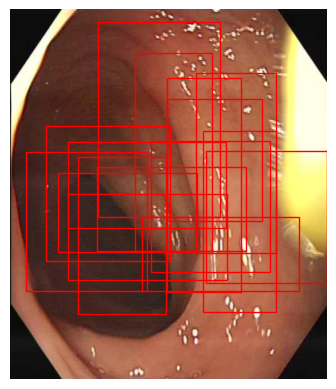

In [36]:
# For inference
model.eval()
# x = [torch.rand(3, 300, 400, device=device), torch.rand(3, 500, 400, device=device)]
# Get a batch of images from the DataLoader
images, targets = next(iter(train_loader))

# Select the first image from the batch for inference
# Assuming your DataLoader returns a batch of images and targets
image_to_infer = images[0].unsqueeze(0).to(device)  # Add batch dimension and move to the device

# Disable gradient computation since we're only doing inference
with torch.no_grad():
    # Perform inference
    predictions = model(image_to_infer)  # Returns predictions

    # Print out the predictions for the first image
    print(predictions[0])
    
# Process the first image and its prediction
image = image_to_infer[0].cpu().numpy()  # Move the tensor to cpu and convert to numpy
image = np.transpose(image, (1, 2, 0))  # Transpose from CxHxW to HxWxC for matplotlib

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis

# Add the predicted bounding boxes
for box in predictions[0]['boxes']:
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

In [32]:
# Train the model
num_epochs = 2
epoch_losses = []  # List to store epoch loss
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0  # Keep track of the total loss for this epoch
    for images, targets in train_loader:
        # Move images and targets to device
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
        
        # print(f"Device of model parameters: {[p.device for p in model.parameters()]}")
        # print(f"Device of images: {images[0].device}")
        # print(f"Device of targets: {targets[0]['boxes'].device}")

        loss_dict = model(images, targets)
        # losses = sum(loss for loss in loss_dict.values())
        losses = sum(loss.to(device) for loss in loss_dict.values())
        
        epoch_loss += losses.item()  # Add the batch loss to the total epoch loss
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
    # Print out the information
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
    # Append the epoch loss to the list
    epoch_losses.append(epoch_loss)

    # Update the learning rate
    lr_scheduler.step()
    # Print learning rate for each parameter group
    for param_group in optimizer.param_groups:
        print(f'Learning Rate: {param_group["lr"]:.6f}')


KeyboardInterrupt



In [ ]:
# After training, you can plot the epoch losses
plt.plot(epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

Saving the model

In [ ]:
# Generate a timestamp or unique identifier
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define a directory to save the models
save_dir = "./saved_models/"

# Create the parent directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the generator model and optimizer state with a unique filename
generator_checkpoint_file = f"{save_dir}generator_checkpoint_{timestamp}.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.state_dict()
}, generator_checkpoint_file)


# # Define filenames with timestamps
# g_losses_filename =  os.path.join(save_dir, f"g_losses_{timestamp}.txt")
# d_losses_filename = os.path.join(save_dir, f"d_losses_{timestamp}.txt")
# 
# # Save G_losses to a file with a timestamp
# with open(g_losses_filename, 'w') as file:
#     for loss in G_losses:
#         file.write(f"{loss}\n")
# 
# # Save D_losses to a file with a timestamp
# with open(d_losses_filename, 'w') as file:
#     for loss in D_losses:
#         file.write(f"{loss}\n")
# 


Loading the model

In [ ]:
# Provide the timestamp you want to load
specified_timestamp = "20231022200319"  # Replace with the desired timestamp

# Load the generator model and optimizer state
checkpoint = torch.load(f'./saved_models/generator_checkpoint_{specified_timestamp}.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.load_state_dict(checkpoint['optimizer_state_dict'])


# # Define the filenames based on the specified timestamp
# specified_g_losses_filename = f"./saved_models/g_losses_{specified_timestamp}.txt"
# specified_d_losses_filename = f"./saved_models/d_losses_{specified_timestamp}.txt"

# # Define lists to store the loaded losses
# loaded_G_losses = []
# loaded_D_losses = []
# 
# # Load G_losses from the file with the specified timestamp
# with open(specified_g_losses_filename, 'r') as file:
#     for line in file:
#         loaded_G_losses.append(float(line.strip()))
# 
# # Load D_losses from the file with the specified timestamp
# with open(specified_d_losses_filename, 'r') as file:
#     for line in file:
#         loaded_D_losses.append(float(line.strip()))
# 
# G_losses = loaded_G_losses
# D_losses = loaded_D_losses